## 

get mean activation/act-difference for different DAN patches 

--> group differences?

* fsaverage5 space (cause beta-maps in this) - so takes old PFM-caDD network maps
--> no small net pieces fildtering yet

--> try other way around? take fsLR PFMs - transform beta-maps to fsLR 
`neuromaps.transforms`

In [1]:
import sys
import os.path as op
import warnings

sys.path.insert(0, '/home/ubuntu/git/parietal_patterns/nets_PFM')
from config import ATLAS_NETWORK_NAMES

import numpy as np
import nibabel as nib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from tqdm.auto import tqdm


/home/ubuntu/miniconda3/envs/numrefields/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [187]:
# ── Atlas ──────────────────────────────────────────────────────────────────
ATLAS = 'caNets_DDnr'   # 'gordon17' | 'caNets_DDnr'

NETWORK_NAMES = ATLAS_NETWORK_NAMES[ATLAS]

# ── Paths ──────────────────────────────────────────────────────────────────
BIDS_ROOT_LARGE  = '/mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk/ds-dnumrisk'
BIDS_ORIG        = '/mnt_03/ds-dnumrisk'

PFM_ROOT         = '/mnt_03/ds-dnumrisk/derivatives/pfm_fslr'
NEUROMAPS_FSLR   = '/home/ubuntu/neuromaps-data/atlases/fsLR'

SUBJECTS = list(range(1, 67))   # sub-01 … sub-65; extend as needed
group_df = pd.read_csv(op.join(BIDS_ROOT_LARGE, 'group_assignment.csv')).set_index('subject')


gradient_folder = op.join(BIDS_ROOT_LARGE, 'derivatives','gradients.tryParams.36P')
activation_folder= op.join(BIDS_ROOT_LARGE, 'derivatives','average_act.glm','mean_maps_nan_filtered.glm')
net_folder = op.join(BIDS_ROOT_LARGE, 'derivatives', 'networks_infomap_full_01')
 

In [3]:
from neuromaps.datasets import fetch_atlas
fslr = fetch_atlas('fsLR', '32k')
fsav5 = fetch_atlas('fsaverage', '10k')

from utils_01 import get_template_vertex_area, load_individual_vertex_areas
tpl_vertex_areas, cortex_mask_L, cortex_mask_R = get_template_vertex_area(NEUROMAPS_FSLR)
cortex_mask_both = np.concatenate([cortex_mask_L, cortex_mask_R])


Valid cortical nodes: L=29696, R=29716, total=59412
Total template cortical area: 178349 mm² (1783.5 cm²)


In [5]:
ref_labels_caNets_fn = op.join(net_folder, f'sub-average_consensusMapping_confspec-36Pscrub3BPfilter.npy') # mapped to ColeAnticevic nets
ref_labels_caNets = np.load(ref_labels_caNets_fn) # 18715

from numrisk.fmri_analysis.gradients.utils import get_basic_mask
mask, labeling_noParcel = get_basic_mask()

ref_labels_caNets_full = np.zeros(20484, dtype=np.float32)
ref_labels_caNets_full[mask] = ref_labels_caNets.astype(np.float32)
ref_labels_caNets_full.shape

(20484,)

In [8]:
from parietal_patterns.utils.surfaces import build_adj_and_coords

adj_L, coords_L = build_adj_and_coords(str(fsav5['white'].L))
adj_R, coords_R = build_adj_and_coords(str(fsav5['white'].R))


In [ ]:
from parietal_patterns.utils.surfaces import centroid_to_lobe

# ── Build reference centroids from the group-average atlas ────────────────
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components

atlas_labels = ref_labels_caNets_full   # (18715,)
atlas_map_L  = atlas_labels[:10242]            # full L hemi, medial wall = 0
atlas_map_R  = atlas_labels[10242:]            # full R hemi, medial wall = 0

atlas_ref_patches = []
dan_patches_map = np.zeros_like(atlas_labels)
n_comp_L = 0
for hemi, adj, coords, hemi_map in [
    ('L', adj_L, coords_L, atlas_map_L),
    ('R', adj_R, coords_R, atlas_map_R),
    ]:
    net_verts = np.where(hemi_map == 5)[0]
    sub_adj   = adj[net_verts][:, net_verts]
    n_comp, comp_labels = connected_components(sub_adj, directed=False)
    if hemi == 'L':
        n_comp_L = n_comp
    for c in range(n_comp):
        verts    = net_verts[comp_labels == c]
        centroid = coords[verts].mean(axis=0)
        lobe = centroid_to_lobe(centroid)
        atlas_ref_patches.append({
            'ref_patch': None,           # assigned below after sorting by size
            'hemi':      hemi,
            'n_verts':   len(verts),
            'centroid':  centroid,
            '_lobe':     lobe,
            'ref_patch' : f"{hemi}_{lobe}"
        })
        verts_hemi = verts if hemi == 'L' else verts + len(atlas_map_L)
        dan_patch_number = c + 1 if hemi == 'L' else c + 1 + n_comp_L
        dan_patches_map[verts_hemi] = dan_patch_number

# removed: Assign names: largest patch per (hemi, lobe) gets the clean name --> remove small pacthes anyway
ref_df = pd.DataFrame(atlas_ref_patches)#.drop(columns='centroid').drop(columns='_lobe')
ref_df = ref_df[ref_df['n_verts'] >= 10] # remove tiny patches that are unlikely to be meaningful and would cause issues with patch-based analyses

ref_centroids = {row['ref_patch']: row['centroid'] for _, row in ref_df.iterrows()}


In [78]:
ref_centroids

{'L_parietal-lateral': array([-29.98376 , -57.739414,  42.435123], dtype=float32),
 'L_frontal-lateral': array([-36.601707,  13.214884,  33.56623 ], dtype=float32),
 'L_temporal': array([-51.38814, -54.33922, -11.47358], dtype=float32),
 'L_frontal-medial-dorsal': array([-8.44241 , 15.477118, 50.158592], dtype=float32),
 'R_parietal-lateral': array([ 30.766388, -56.280342,  43.064346], dtype=float32),
 'R_frontal-lateral': array([36.91766 , 16.143173, 32.591705], dtype=float32),
 'R_frontal-medial-dorsal': array([ 8.423902, 18.484924, 49.38018 ], dtype=float32),
 'R_temporal': array([ 54.334045, -52.277084, -11.775641], dtype=float32),
 'R_frontal-medial': array([ 23.203995,  40.76195 , -12.589015], dtype=float32),
 'R_frontal-insula': array([31.45994  , 23.630095 , -1.1675851], dtype=float32)}

In [97]:
sub = '01'

lower_threshold = -1.31
upper_threshold  =  1.42
beta_maps = {}
for stim in [1,2]:
    # load masked_mean_maps
    fname = f"sub-{sub}_stim-{stim}_masked_nan_filtered.npy"
    fpath = op.join(activation_folder,f'stim-{stim}', f'sub-{sub}', fname)
    d = np.load(fpath)
    d[(d < lower_threshold) | (d > upper_threshold)] = np.nan
    beta_maps[stim] = d

beta_maps = np.array([beta_maps[1], beta_maps[2]]).T
nets = np.load(op.join(net_folder, f'sub-{sub}_consensusMapping_confspec-36Pscrub3BPfilter.npy'))


In [98]:
cortex_mask_both = mask
cortex_mask_L = cortex_mask_both[:10242]
cortex_mask_R = cortex_mask_both[10242:]

In [105]:
np.nanmean(beta_maps)

0.044405933

In [196]:
fpath

'/mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk/ds-dnumrisk/derivatives/average_act.glm/mean_maps_nan_filtered.glm/stim-2/sub-01/sub-01_stim-2_masked_nan_filtered.npy'

In [216]:
from scipy.spatial.distance import cdist

def get_dan_patches_act(sub, target_label=5):
    sub = f"{sub:02d}"
    beta_maps = {}
    for stim in [1,2]:
        # load masked_mean_maps
        fname = f"sub-{sub}_stim-{stim}_masked_nan_filtered.npy"
        fpath = op.join(activation_folder,f'stim-{stim}', f'sub-{sub}', fname)
        d = np.load(fpath)
        d[(d < lower_threshold) | (d > upper_threshold)] = np.nan
        beta_maps[stim] = d
    beta_maps = np.array([beta_maps[1], beta_maps[2]]).T

    nets = np.load(op.join(net_folder, f'sub-{sub}_consensusMapping_confspec-36Pscrub3BPfilter.npy'))
    net_label_map = np.zeros(cortex_mask_both.shape, dtype=int)
    net_label_map[cortex_mask_both] = nets

    n_L = cortex_mask_L.shape[0]
    n_L_masked = cortex_mask_L.sum()
    patches = []

    for hemi, adj, coords, cort_mask, cort_labels, cort_betas in [
        ('L', adj_L, coords_L, cortex_mask_L, net_label_map[:n_L], beta_maps[:n_L_masked]),
        ('R', adj_R, coords_R, cortex_mask_R, net_label_map[n_L:], beta_maps[n_L_masked:]),
        ]:

        # net labels
        hemi_net_map = np.zeros(coords.shape[0], dtype=int)
        hemi_net_map[cort_mask] = cort_labels[cort_mask]

        # activations
        hemi_beta1_map = np.zeros(coords.shape[0])
        hemi_beta1_map[cort_mask] = cort_betas[:, 0] # so indices match
        hemi_beta2_map = np.zeros(coords.shape[0])
        hemi_beta2_map[cort_mask] = cort_betas[:, 1] # so indices match

        # find patches within DAN (== connected components of DAN vertices)
        net_verts = np.where(hemi_net_map == target_label)[0] # indices of vertices belonging to DAN
        sub_adj = adj[net_verts][:, net_verts] # adjacency information on all vetices in DAN (N_vert_net x N_vert_net)
        n_comp, comp_labels = connected_components(sub_adj, directed=False)

        for c in range(n_comp):
            verts    = net_verts[comp_labels == c] # indices of vertices belong to that patch
            centroid = coords[verts].mean(axis=0)

            # find best matching ref patch label name
            candidates = {k: v for k, v in  ref_centroids.items() if k.startswith(hemi)}
            names = list(candidates.keys())
            dists = cdist([centroid], [candidates[n] for n in names])[0]
            best  = names[np.argmin(dists)]

            patches.append({
                'subject':   int(sub),
                'hemi':     hemi,
                'n_verts':  len(verts),
                #'group':     group_df.loc[p['sub_id'], 'group'] if p['sub_id'] in group_df.index else np.nan,

                #'centroid': centroid,
                'ref_patch': best,
                'stim1_beta': np.nanmean(hemi_beta1_map[verts]),
                'stim2_beta': np.nanmean(hemi_beta2_map[verts]),
            })
    return patches

In [217]:
# ── Collect all subjects ───────────────────────────────────────────────────
all_patches = []
for sub_id in tqdm(SUBJECTS):
    try:    
        all_patches.extend(get_dan_patches_act(sub_id))
    except Exception as e:
        print(f"Error processing subject {sub_id}: {e}")

  0%|          | 0/66 [00:00<?, ?it/s]/tmp/ipykernel_788112/1768331875.py:61: RuntimeWarning: Mean of empty slice
  'stim1_beta': np.nanmean(hemi_beta1_map[verts]),
/tmp/ipykernel_788112/1768331875.py:62: RuntimeWarning: Mean of empty slice
  'stim2_beta': np.nanmean(hemi_beta2_map[verts]),
 12%|█▏        | 8/66 [00:00<00:01, 35.28it/s]

Error processing subject 2: [Errno 2] No such file or directory: '/mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk/ds-dnumrisk/derivatives/networks_infomap_full_01/sub-02_consensusMapping_confspec-36Pscrub3BPfilter.npy'


100%|██████████| 66/66 [00:01<00:00, 33.32it/s]


In [218]:
df_patches = pd.DataFrame(all_patches)
df_patches[df_patches['n_verts'] >= 100]

df_patches['act_diff'] = df_patches['stim2_beta'] - df_patches['stim1_beta']

In [219]:
group_df

,group
subject,
1,0
2,1
3,0
4,1
5,0
...,...
62,0
63,0
64,0


In [224]:
df_patches.set_index('subject').join(group_df)

,hemi,n_verts,ref_patch,stim1_beta,stim2_beta,act_diff,group
subject,,,,,,,
1,L,855,L_parietal-lateral,0.087891,0.077385,-0.010506,0
1,L,2,L_temporal,0.364482,0.335218,-0.029265,0
1,L,185,L_frontal-lateral,0.081077,0.082078,0.001001,0
1,L,61,L_temporal,0.097540,0.119949,0.022410,0
1,L,221,L_temporal,0.066359,0.078365,0.012006,0
...,...,...,...,...,...,...,...
66,R,2,R_frontal-medial,0.051022,0.034806,-0.016217,0
66,R,1,R_parietal-lateral,0.065250,0.109468,0.044218,0
66,R,1,R_temporal,0.010777,-0.008585,-0.019362,0


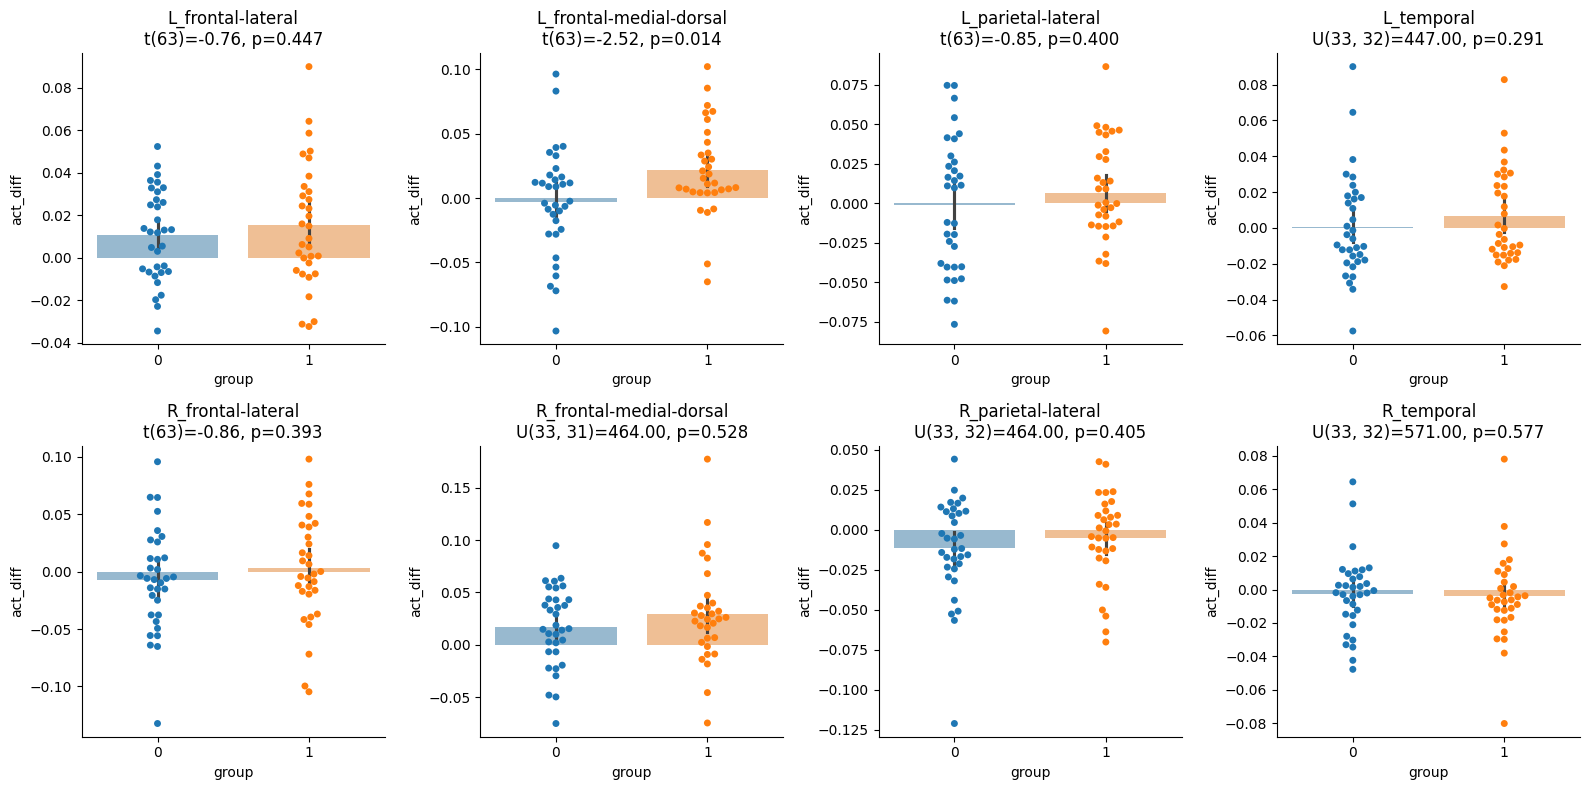

In [234]:
# only 4 largest patches
# per subject multiple patches assigned to one reference patch..... 
# take sum or select largest? --> currently sum!
from parietal_patterns.utils.statistics import between_group_comparison

N_top_patches = 8
top_patches = pd.DataFrame(atlas_ref_patches).drop(columns='centroid').sort_values('n_verts', ascending=False).reset_index()['ref_patch'].values[:N_top_patches]
df_top_patches = df_patches[df_patches['ref_patch'].isin(top_patches)]

y_var = 'act_diff'# 'n_verts' # 

fig, axes = plt.subplots(2, N_top_patches//2, figsize=(2 * N_top_patches, 8))

for ax, patch in zip(axes.flatten(), sorted(df_top_patches['ref_patch'].unique())):
    sub = df_top_patches[df_top_patches['ref_patch'] == patch].reset_index().copy()
    sub = sub.join(group_df, on='subject')
    sub = pd.DataFrame(sub.groupby(['subject', 'group'])[y_var].mean()).reset_index()
    sns.barplot(data=sub, x='group', hue='group', y=y_var, alpha=0.5, legend=False, ax=ax)
    sns.swarmplot(data=sub, x='group', hue='group', y=y_var, size=5, legend=False, ax=ax)

    stats, test = t, p = between_group_comparison(sub, y_var, group_names = [0,1])
    ax.set_title(f'{patch}\n{test}={stats.statistic:.2f}, p={stats.pvalue:.3f}')
    sns.despine()

#axes[0].set_ylabel('cm²' if (y_var == 'ind_area') else 'vertex count')

plt.tight_layout(); plt.show()

In [172]:
from scipy.spatial.distance import cdist

target_label = 5

# Reconstruct cortex-space label map (18715 --> 20484)
surf_map_cortex = np.zeros(cortex_mask_both.shape, dtype=int)
surf_map_cortex[cortex_mask_both] = nets

n_L = cortex_mask_L.shape[0]
n_L_masked = cortex_mask_L.sum()
patches = []
for hemi, adj, coords, cort_mask, cort_labels, cort_betas in [
    ('L', adj_L, coords_L, cortex_mask_L, surf_map_cortex[:n_L], beta_maps[:n_L_masked]),
    ('R', adj_R, coords_R, cortex_mask_R, surf_map_cortex[n_L:], beta_maps[n_L_masked:]),
    ]:

    # net labels
    hemi_net_map = np.zeros(coords.shape[0], dtype=int)
    hemi_net_map[cort_mask] = cort_labels[cort_mask]

    # activations
    hemi_beta1_map = np.zeros(coords.shape[0])
    hemi_beta1_map[cort_mask] = cort_betas[:, 0] # so indices match
    hemi_beta2_map = np.zeros(coords.shape[0])
    hemi_beta2_map[cort_mask] = cort_betas[:, 1] # so indices match

    # find patches within DAN (== connected components of DAN vertices)
    net_verts = np.where(hemi_net_map == target_label)[0] # indices of vertices belonging to DAN
    sub_adj = adj[net_verts][:, net_verts] # adjacency information on all vetices in DAN (N_vert_net x N_vert_net)
    n_comp, comp_labels = connected_components(sub_adj, directed=False)

    for c in range(n_comp):
        verts    = net_verts[comp_labels == c] # indices of vertices belong to that patch
        centroid = coords[verts].mean(axis=0)

        # find best matching ref patch label name
        candidates = {k: v for k, v in  ref_centroids.items() if k.startswith(hemi)}
        names = list(candidates.keys())
        dists = cdist([centroid], [candidates[n] for n in names])[0]
        best  = names[np.argmin(dists)]

        patches.append({
            'sub_id':   int(sub),
            'hemi':     hemi,
            'n_verts':  len(verts),
            #'centroid': centroid,
            'ref_patch': best,
            'stim1_beta': np.nanmean(hemi_beta1_map[verts]),
            'stim2_beta': np.nanmean(hemi_beta2_map[verts]),
        })

In [173]:
df_patches = pd.DataFrame(patches)
df_patches[df_patches['n_verts'] > 100]
# take biggest or sum of patches per label?

,sub_id,hemi,n_verts,ref_patch,stim1_beta,stim2_beta
0,1,L,855,L_parietal-lateral,0.087891,0.077385
2,1,L,185,L_frontal-lateral,0.081077,0.082078
4,1,L,221,L_temporal,0.066359,0.078365
67,1,R,901,R_parietal-lateral,0.063966,0.050922
71,1,R,138,R_frontal-lateral,0.061243,0.051914
73,1,R,129,R_frontal-lateral,0.116390,0.090644
75,1,R,121,R_temporal,0.046408,0.060868
